# Image Classification with Deep Learning Using TensorFlow

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from pathlib import Path
import os

In [17]:
# data directory
data_dir = Path.cwd() / 'data'

# assets
partitions = ['Train', 'Test', 'Meta']
csv_files = ['Train.csv', 'Test.csv', 'Meta.csv']

metrics = []

# loop and gather metrics
for folder,csv in zip(partitions, csv_files):
    folder_path =data_dir / folder
    csv_path= data_dir / csv
    
    # count images to search recursively since 43 subfolders
    if folder_path.exists():
        img_count= sum(1 for _ in folder_path.rglob('*.png'))
    else:
        img_count= "Folder Missing"
        
    # count csv rows
    if csv_path.exists():
        df = pd.read_csv(csv_path, usecols=[0]) 
        csv_rows = len(df)
    else:
        csv_rows = "CSV Missing"
        
    # append metrics list
    metrics.append({
        'Partition': folder,
        'Image Files Found': img_count,
        'CSV Records': csv_rows,
        'Integrity Check': 'Pass' if img_count == csv_rows else 'Fail / Mismatch'
    })

# create and display summary df
eda_summary_df =pd.DataFrame(metrics)

# set index clean display
eda_summary_df.set_index('Partition', inplace=True)

# display
display(eda_summary_df)

,Image Files Found,CSV Records,Integrity Check
Partition,,,
Train,39209,39209,Pass
Test,12630,12630,Pass
Meta,43,43,Pass


In [2]:
# define path
DATA_DIR = 'data/'

# load train data
train_df = pd.read_csv(os.path.join(DATA_DIR, 'Train.csv'))

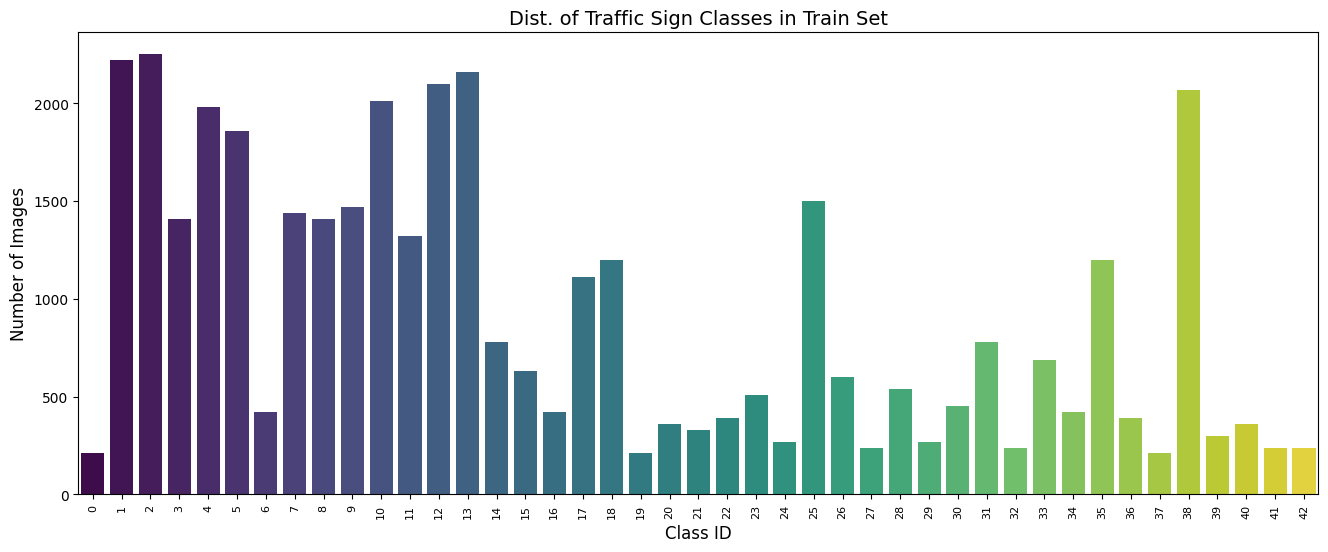

In [3]:
# distribution of classes
plt.figure(figsize=(16, 6))
sns.countplot(data=train_df, x='ClassId',hue='ClassId', palette='viridis',legend=False)
plt.title('Dist. of Traffic Sign Classes in Train Set', fontsize=14)
plt.xlabel('Class ID', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.show()

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

Found 39209 validated image filenames belonging to 43 classes.


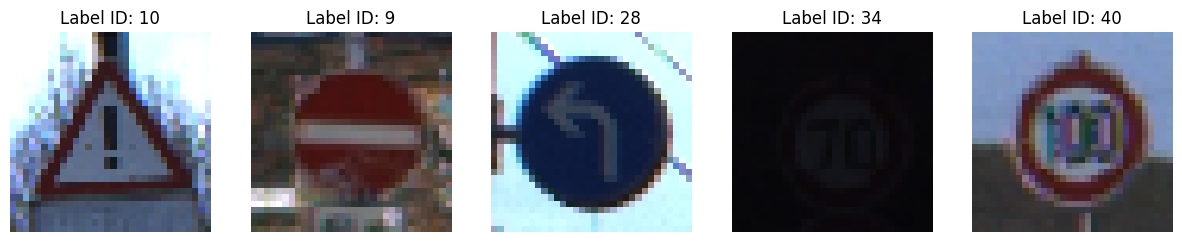

In [16]:
# current working directory
data_dir = Path.cwd() / 'data'

# load df from data folder
train_df= pd.read_csv(data_dir / 'Train.csv')

# convert ClassId to string Keras category generator
train_df['ClassId']= train_df['ClassId'].astype(str)

# Iinitialize generator
datagen =ImageDataGenerator(rescale=1./255)

# create data iterator
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=str(data_dir),     # Keras start looking inside the data/ folder
    x_col='Path',                # Keras append csv Path (ex.'Train/0/..')
    y_col='ClassId',             
    target_size=(32, 32),        # standardize png signs 32x32
    batch_size=5,                # 5 images for test
    class_mode='categorical',
    shuffle=True
)

# fetch batch and visualize
images, labels = next(train_generator)

plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i]) 
    plt.title(f"Label ID: {labels[i].argmax()}") 
    plt.axis('off')
plt.show()

# Single Batch Overfit Test Run

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [23]:
# one static batch from generator
x_batch, y_batch = next(train_generator)

# build simple cnn
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(43, activation='softmax') 
])

# 3optimizer industry-standard 1e-3 starting rate
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# train directly on static batch arrays
print("Start single batch smoke test..")
history = model.fit(
    x_batch, y_batch,
    epochs=25,
    verbose=1
)

Start single batch smoke test..
Epoch 1/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 3.7503
Epoch 2/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4000 - loss: 3.5394
Epoch 3/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6000 - loss: 3.3279
Epoch 4/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6000 - loss: 3.0766
Epoch 5/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.6000 - loss: 2.7835
Epoch 6/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6000 - loss: 2.4960
Epoch 7/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6000 - loss: 2.2807
Epoch 8/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.4000 - loss: 2.1341
Epoch 9/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4000 - loss: 2.0182
Epoch 10/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4000 - loss: 1.9047
Epoch 11/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.4000 - loss: 1.7758
Epoch 12/25
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/s

In [ ]:
# Test validates moving from local to cloud / 80% accuracy 

# Google Colab - Cloud Phase

In [ ]:
# dependencies first
!pip install mlflow dagshub tensorflow pandas scikit-learn

In [ ]:
from google.colab import drive
from google.colab import userdata
import zipfile
import os

In [ ]:
# mount drive
drive.mount('/content/drive')

# root of Google Drive
zip_path = '/content/drive/MyDrive/TRAFFIC_SIGN.zip'
extract_path = '/content/data'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
print("Data ready..")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import pandas as pd
import numpy as np
import dagshub
import mlflow
import mlflow.tensorflow

In [ ]:
# secret value
api_key = userdata.get('dagshub_token')

# MLflow Tracking set up
os.environ['MLFLOW_TRACKING_USERNAME'] = "removed user name"
os.environ['MLFLOW_TRACKING_PASSWORD'] = api_key

# initialize connection
dagshub.init(repo_owner='serranoe.e20', repo_name='Traffic-Sign-Project', mlflow=True)
mlflow.tensorflow.autolog()

In [ ]:
# load data
train_df = pd.read_csv('/content/data/Train.csv')
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_df['ClassId'] = train_df['ClassId'].astype(str)

# 20% validation split to track real performance vs overfitting
datagen =ImageDataGenerator(rescale=1./255,validation_split=0.2)

train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/data',
    x_col='Path',
    y_col='ClassId',
    target_size=(32, 32),
    batch_size=64, # 64 batch size
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/data',
    x_col='Path',
    y_col='ClassId',
    target_size=(32, 32),
    batch_size=64,
    class_mode='categorical',
    subset='validation'

In [ ]:
# calculate class weights
print("Calculating class weights to handle imbalance..")

# numerical labels from  generator
true_classes =train_generator.classes
class_indices= train_generator.class_indices

# unique classes
unique_classes =np.unique(true_classes)

# compute  weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=true_classes
)
# package into dict for tf
class_weights_dict = dict(zip(unique_classes, weights))
print("Class weights calculated successfully..")

# Architecture & Training

In [ ]:
# build model
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # dropout prevent overfitting full dataset
    layers.Dense(43, activation='softmax')
])

# compile & train
lr_schedule = tf.keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=1e-3,
    first_decay_steps=1000,
    t_mul=2.0,
    m_mul=0.9
)

optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# execute run / opens  notebook & start recording
with mlflow.start_run(run_name="GTSRB_Weighted_Run_02_Shuffled"):
    print("Starting full GPU training phase..")
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=10,
        class_weight=class_weights_dict, # weights applied here
        verbose=1
    )

# Model Testing

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report

In [ ]:
# load test csv
print("Loading test data..")
test_df = pd.read_csv('/content/data/Test.csv')
test_df['ClassId'] = test_df['ClassId'].astype(str)
print("Test data loaded successfully..")

In [ ]:
# test generator / shuffle=False so predicts align with csv rows
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='/content/data',
    x_col='Path',
    y_col='ClassId',
    target_size=(32, 32),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

In [ ]:
# evaluate model
print("\nRunning evaluation on unseen data..")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)

print(f"FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print(f"FINAL TEST LOSS:     {test_loss:.4f}")

In [ ]:
# classification report / predict every image in the test set
predictions = model.predict(test_generator, verbose=1)

# convert probabilities into final class choices
predicted_classes = np.argmax(predictions, axis=1)

# true answers
true_classes = test_generator.classes

# breakdown for all 43 classes
print(classification_report(true_classes, predicted_classes))